In [1]:

import pandas as pd
data = pd.read_csv(r"C:\Users\Eddie\OneDrive\Desktop\Medical_Cost_Personal_Data\Medical Cost Personal Dataset.csv")
print(data.head())

print(data.info())

print(data.describe())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None
               age          bmi     children       charges
count  1338.000000  1338.000000 

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
1


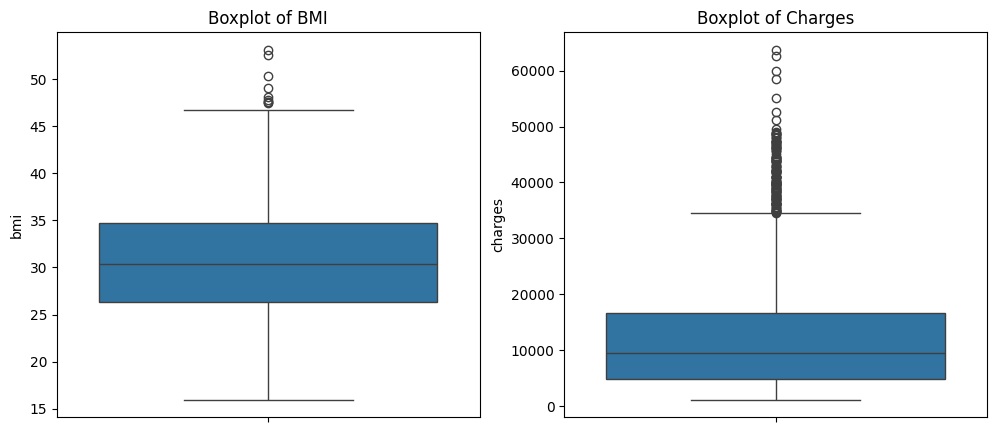

   age     bmi  children      charges  sex_male  smoker_yes  region_northwest  \
0   19  27.900         0  16884.92400     False        True             False   
1   18  33.770         1   1725.55230      True       False             False   
2   28  33.000         3   4449.46200      True       False             False   
3   33  22.705         0  21984.47061      True       False              True   
4   32  28.880         0   3866.85520      True       False              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  


In [2]:
#Cleaning data
print(data.isnull().sum())

print(data.duplicated().sum())

        #Outlier detection using boxplots
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(y=data['bmi'])
plt.title("A Boxplot That shows BMI")

plt.subplot(1,2,2)
sns.boxplot(y=data['charges'])
plt.title("A Boxplot Showing  Charges")
plt.show()


         #Encode categorical variables
data_encoded = pd.get_dummies(data, columns=['sex', 'smoker', 'region'], drop_first=True)
print(data_encoded.head())

#Feature scaling discussion: Not required for linear since all the values are near donot need scaling the as we prepare for a modelling

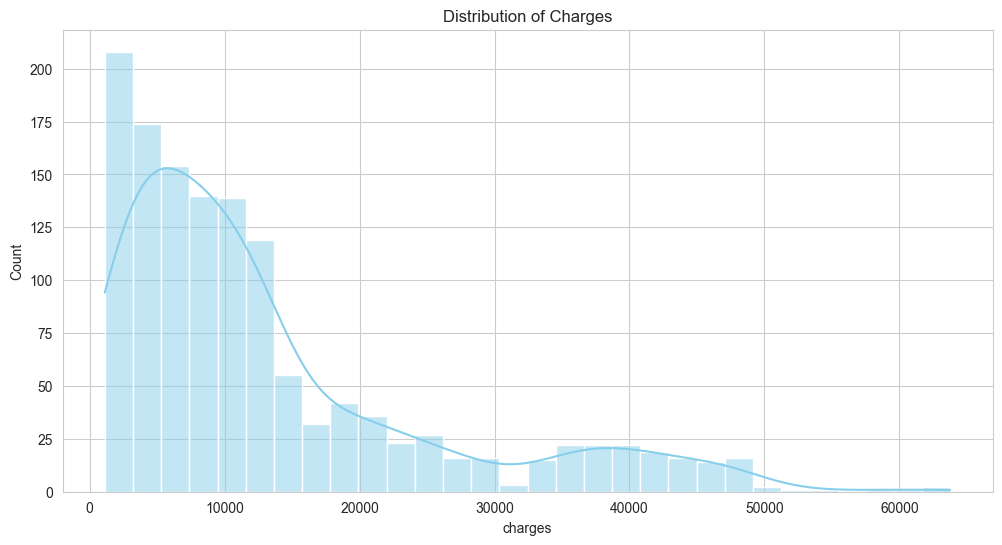

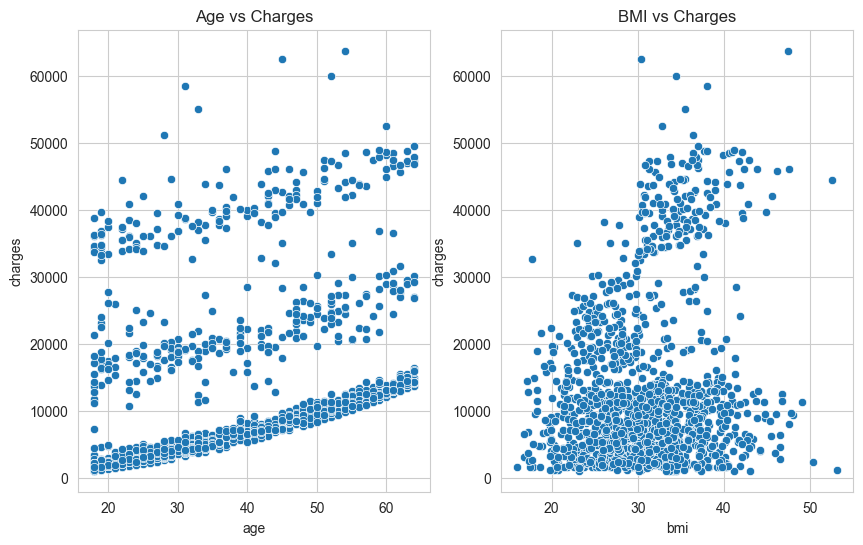

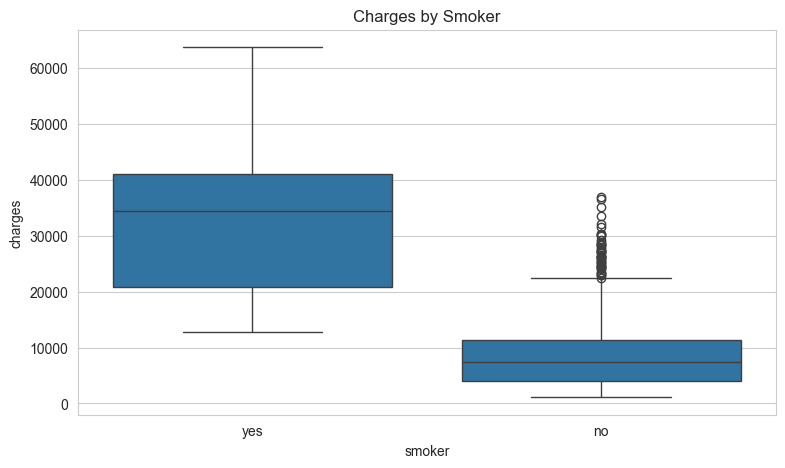

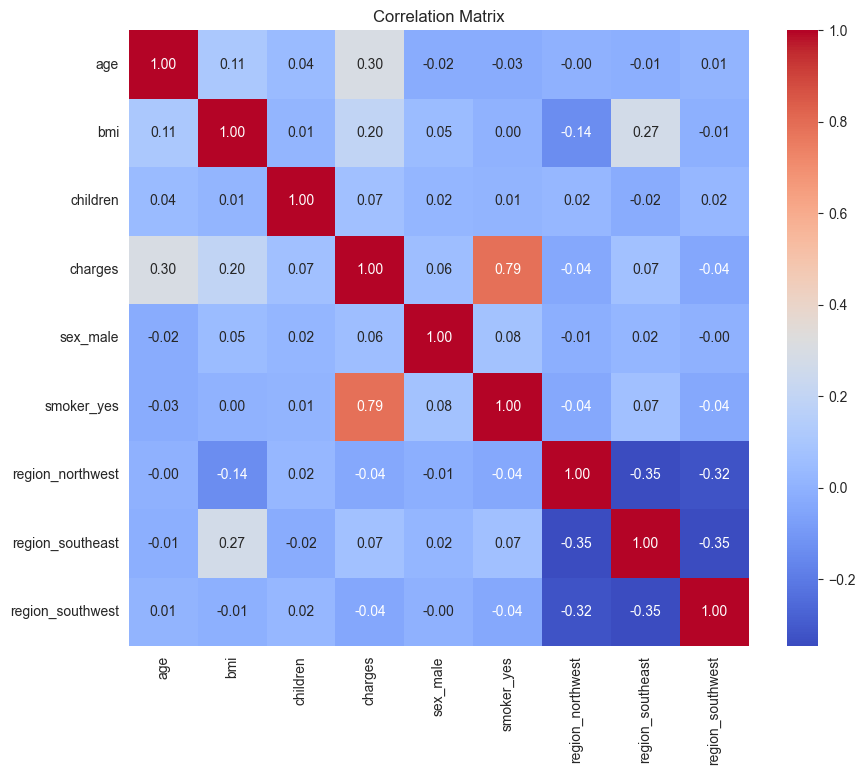

In [6]:
#Exploratory data analysis
sns.set_style("whitegrid")

                #Histogram of charges + skewness
plt.figure(figsize=(12,6))
sns.histplot(data['charges'], kde=True, color='skyblue')
plt.title("A histogram showing Distribution of Charges")
plt.show()

             #Scatter plots
plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
sns.scatterplot(x='age', y='charges', data=data)
plt.title("A scattered plot showing Age against Charges")

plt.subplot(1,2,2)
sns.scatterplot(x='bmi', y='charges', data=data)
plt.title(" A PLOT SHOWING BMI AGAINST Charges")
plt.show()

        #Boxplot: Charges by Smoker
plt.figure(figsize=(9,5))
sns.boxplot(x='smoker', y='charges', data=data)
plt.title(" A BOXPLOT SHOWING Charges DUE TO Smoker")
plt.show()

             #Correlation Matrix
corr = data_encoded.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("A Graph showing a Correlation Matrix")
plt.show()

In [13]:

from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

 #Simple Linear Regression
X_simple = data[['bmi']] 
y = data['charges']       

model_simple = LinearRegression()
model_simple.fit(X_simple, y)

print(" Simple Linear Regression")
print(f"Intercept: {model_simple.intercept_}")
print(f"Slope (BMI coefficient): {model_simple.coef_[0]}")


     #Identifying categorical columns
categorical_cols = ['sex', 'smoker', 'region']  

data_encoded = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

X_multi = data_encoded.drop('charges', axis=1)
y = data_encoded['charges']

    #Making all columns are numeric
X_multi = X_multi.astype(float)

       #Add intercept for statsmodels
X_multi = sm.add_constant(X_multi)

        #Fiting a Multiple Linear Regression using statsmodels

model_multi = sm.OLS(y, X_multi).fit()

print("\nMultiple Linear Regression Summary")
print(model_multi.summary())

 Simple Linear Regression
Intercept: 1192.9372089611497
Slope (BMI coefficient): 393.87303079739524

Multiple Linear Regression Summary
                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.8
Date:                Sat, 28 Feb 2026   Prob (F-statistic):               0.00
Time:                        13:00:24   Log-Likelihood:                -13548.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1329   BIC:                         2.716e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025  

=== Model Evaluation Metrics ===
RMSE: 5812.10, MAE: 4145.45, R²: 0.742


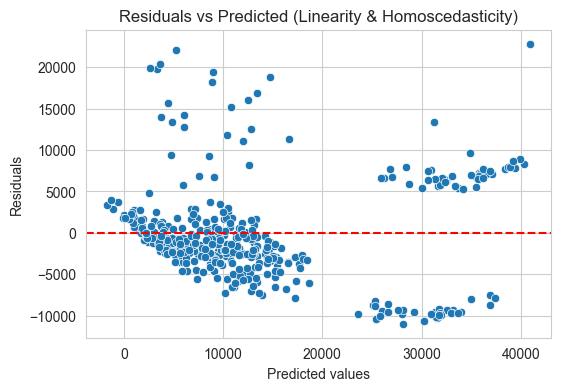

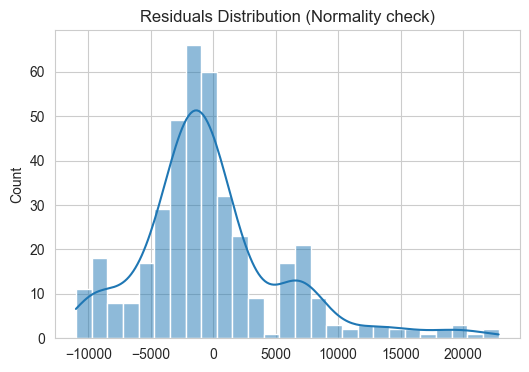

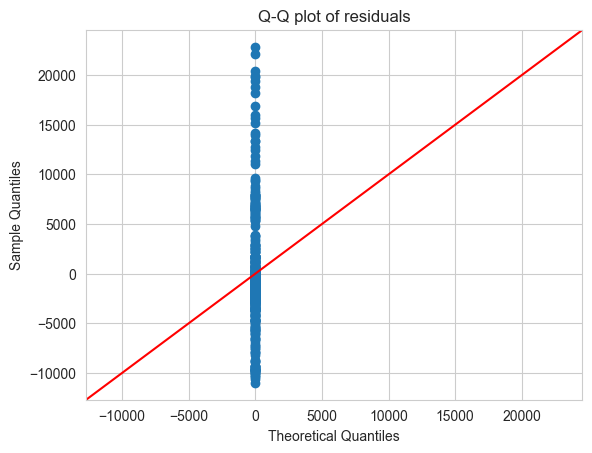

Durbin-Watson statistic (independence of residuals): 2.075

=== Variance Inflation Factor (VIF) ===
            feature        VIF
0             const  35.527488
1               age   1.016822
2               bmi   1.106630
3          children   1.004011
4          sex_male   1.008900
5        smoker_yes   1.012074
6  region_northwest   1.518823
7  region_southeast   1.652230
8  region_southwest   1.529411


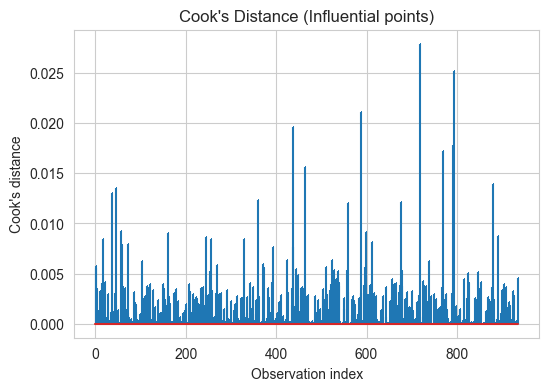

Observations with high influence (Cook's D > 0.003): [  1   2   4  10  14  18  22  38  44  46  56  58  62  66  73  85 104 115
 118 122 128 149 153 161 175 179 207 210 234 239 244 253 254 256 259 266
 269 278 291 329 343 349 359 370 373 381 391 394 424 426 434 437 438 445
 449 455 458 461 464 503 511 519 520 522 523 529 532 536 537 539 540 557
 558 560 587 588 594 596 599 608 613 617 643 656 660 663 665 671 675 676
 677 678 679 690 701 718 724 727 731 739 767 768 789 791 794 815 824 827
 847 848 853 877 879 891 900 904 908 924 934]


In [14]:
#model evalutions and assumptions of this linear regression model

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
import scipy.stats as stats


# Identify categorical columns
categorical_cols = ['sex', 'smoker', 'region']  

  #encode categorical variables
data_encoded = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

X = data_encoded.drop('charges', axis=1).astype(float)
y = data_encoded['charges']

      #Add intercept for statsmodels
X = sm.add_constant(X)

#Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Fit OLS model on training data
model = sm.OLS(y_train, X_train).fit()

# Predict on test data
y_pred = model.predict(X_test)

          #Evaluation metrics

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = model.rsquared
print(" Model Evaluation Metrics ")
print(f"RMSE: {rmse:.1f}, MAE: {mae:.2f}, R²: {r2:.3f}")


       #Residuals
residuals = y_test - y_pred

#Residuals vs Predicted (linearity & homoscedasticity)
plt.figure(figsize=(8,5))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("A Scattered plot showing Residuals vs Predicted (Linearity & Homoscedasticity)")
plt.show()

   #Histogram of residuals (normality)
plt.figure(figsize=(8,4))
sns.histplot(residuals, kde=True)
plt.title("A histogram showing Residuals Distribution (Normality check)")
plt.show()

# Q-Q plot(normality)
sm.qqplot(residuals, line='45')
plt.title("a plot showing Q-Q plot of residuals")
plt.show()

   #Durbin-Watson test (independence)
dw = durbin_watson(model.resid)
print(f"Durbin-Watson statistic (independence of residuals): {dw:.3f}")


   #Multicollinearity check

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print("\n Variance Inflation Factor (VIF)")
print(vif_data)


   #Influential points (Cook's distance)
influence = model.get_influence()
(c, p) = influence.cooks_distance
plt.figure(figsize=(8,4))
plt.stem(np.arange(len(c)), c, markerfmt=",")
plt.title("Cook's Distance (Influential points)")
plt.xlabel("Observation index")
plt.ylabel("Cook's distance")
plt.show()

    #flag points with high influence
threshold = 4 / len(X)
influential_points = np.where(c > threshold)[0]
print(f"Observations with high influence (Cook's D > {threshold:.3f}): {influential_points}")

In [19]:
 #Key factor Increasing Charges
#smoker_yes` has the largest positive coefficient (~$23,000), increasing insurance charges most.
 # Interpretation: Smokers are higher risk clients.

    ### #Effect of BMI
#Coefficient ~ $320 per unit increase.
 #Interpretation: Each 1-unit BMI increase raises charges by $320.


    ### #Effect of Age
#Coefficient ~ $260 per year.
 #Older clients pay more, holding other factors constant.

    ### #Effect of Children
#Each additional child increases charges ~$480.

    ### #Effect of Sex and Region
#sex_male` and region dummies are mostly insignificant.
#Minimal impact on charges compared to smoking, BMI, and age.


    #hree Actionable Business Recommendations
1. #Smoking Risk Management Strategy** – Offer premium discounts for smoking cessation.  
2. #Preventive Health & BMI Programs** – Incentivize healthy BMI to reduce costs.  
3. #Risk-Based Premium Structuring** – Tailor plans based on age, BMI, and smoking.

3.0

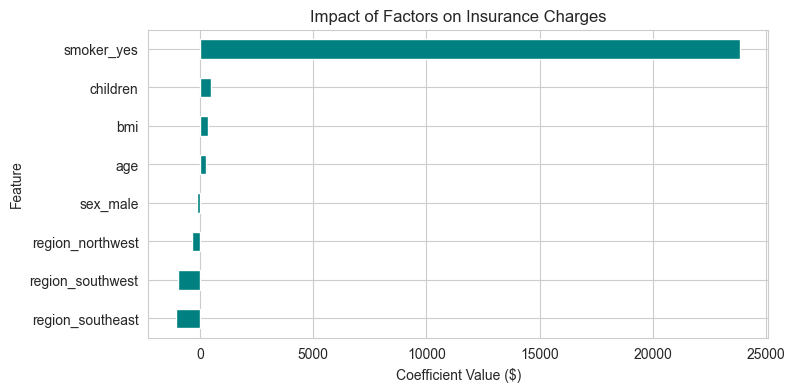

In [20]:
# Visualization of coefficient impacts
coef = model_multi.params[1:] 
plt.figure(figsize=(8,4))
coef.sort_values().plot(kind='barh', color='teal')
plt.title("Impact of Factors on Insurance Charges")
plt.xlabel("Coefficient Value ($)")
plt.ylabel("Feature")
plt.show()